# Certified Flexibility Orchestration — Experimental Notebook

**Companion to:** *Certified Flexibility Orchestration for Grid-Responsive Buildings with
Electric Vehicles: A Unified Variational Framework with Distribution-Free Reliability
Guarantees* (Special Issue: *Grid-responsive Energy Flexible Buildings with Electric
Vehicles for Low-carbon Transitions*).

This notebook produces every quantitative result in Section 4 of the manuscript.

---

### What this notebook does

1. Generates a physically-grounded synthetic scenario (weather, PV, carbon intensity,
   tariff, occupancy, and a stochastic EV fleet with an early-departure hazard).
2. Simulates a coupled building–EV plant: RC thermal model, HVAC, PV, stationary
   storage with degradation, and mobility-constrained EV clusters.
3. Implements eight controllers: uncontrolled, TOU rule, carbon rule, MPC with perfect
   and realistic forecasts, robust MPC, and the proposed **CFO**.
4. Certifies deliverable flexibility by split-conformal calibration on the system's own
   delivery record, and applies the selective *act / de-rate / abstain* policy.
5. Reports carbon, cost, comfort, mobility and degradation **alongside** the reliability
   metrics the incumbent literature omits: empirical coverage, delivery ratio,
   false-activation and missed-opportunity rates, and the coverage–value curve.

### Honest scope

The exogenous data are **synthetic**, not measured. Every generator sits behind a small
interface (`Scenario._make_*`, `Scenario.resize_events`) so that real weather, grid-carbon
and charging-session traces can be substituted without touching the controllers or the
certification layer. Nothing here constitutes field validation, and the manuscript says so.

### Runtime

`DAYS = 42` takes roughly 20–30 minutes on 2 cores. Set `QUICK = True` for a ~5 minute
smoke run that reproduces the structure but not the statistics.

In [1]:
import os, time, warnings, itertools
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cfo_lib import (BuildingCfg, FleetCfg, SimCfg, Scenario, Plant, MPCCore,
                     ConformalCertifier, Uncontrolled, TOURule, CarbonRule,
                     MPCController, CFOController, run, measure_delivery,
                     summarise)

QUICK = False
DAYS  = 14 if QUICK else 42
SEED  = 20261231
os.makedirs("figs", exist_ok=True); os.makedirs("out", exist_ok=True)

# --- figure style -----------------------------------------------------------
NAVY, STEEL, AMBER = "#123A5E", "#1B5E8C", "#C9930A"
RED, GREEN, GREY   = "#B03A2E", "#1E7A5A", "#8A8F98"
mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.autolayout": True,
})
print(f"configuration: DAYS={DAYS}  QUICK={QUICK}")

configuration: DAYS=42  QUICK=False


## 1. Scenario and plant

`Scenario` produces the exogenous series. The EV fleet is described as behavioural
clusters with stochastic arrival, declared departure, **actual** departure (an
18% early-departure hazard), arrival SOC, required departure SOC, and a participation
propensity. The gap between *declared* and *actual* departure is the dominant source of
broken commitments, and it is what the certification layer must learn to price.

In [2]:
scfg = SimCfg(days=DAYS, seed=SEED)
bcfg = BuildingCfg()
fcfg = FleetCfg()

sc   = Scenario(bcfg, fcfg, scfg)
core = MPCCore(bcfg, fcfg, scfg)

print(f"horizon steps       : {sc.T} ({scfg.days} days)")
print(f"ambient temperature : {sc.tamb.min():.1f} .. {sc.tamb.max():.1f} degC")
print(f"PV peak             : {sc.pv.max():.0f} kW of {bcfg.pv_kwp:.0f} kWp")
print(f"grid carbon         : {sc.carbon.min():.2f} .. {sc.carbon.max():.2f} kgCO2/kWh")
print(f"EV fleet            : {sum(fcfg.cluster_sizes)} vehicles in "
      f"{fcfg.n_clusters} clusters")

horizon steps       : 1008 (42 days)
ambient temperature : -3.4 .. 33.3 degC
PV peak             : 207 kW of 180 kWp
grid carbon         : 0.19 .. 0.66 kgCO2/kWh
EV fleet            : 23 vehicles in 3 clusters


### 1.1 Sizing the grid service requests

A flexibility market asks for a reduction relative to the position a site has **scheduled**,
not relative to its unmanaged demand. Sizing requests against an unmanaged profile makes
them unsatisfiable for an already-optimised building — the controller has typically
emptied its evening import already — and then the experiment measures nothing.

We therefore take the realistic-forecast MPC operating *without any commitment* as the
declared day-ahead schedule, and size every request as a fraction of it. The same event
list is then faced by every controller, so the comparison is fair.

In [3]:
t0 = time.time()
_, schedule = run(sc, lambda s_, c_: MPCController(s_, c_), core, respond=False)
sc.resize_events(schedule["imp"].values)
print(f"{len(sc.events)} requests generated in {time.time()-t0:.0f}s")
mags = np.array([e[2] for e in sc.events])
durs = np.array([e[1] for e in sc.events])
print(f"magnitude : {mags.min():.0f} .. {mags.max():.0f} kW (mean {mags.mean():.0f})")
print(f"duration  : {np.bincount(durs)[1:]} events of 1/2/3 h")

88 requests generated in 13s
magnitude : 9 .. 311 kW (mean 62)
duration  : [42 38  8] events of 1/2/3 h


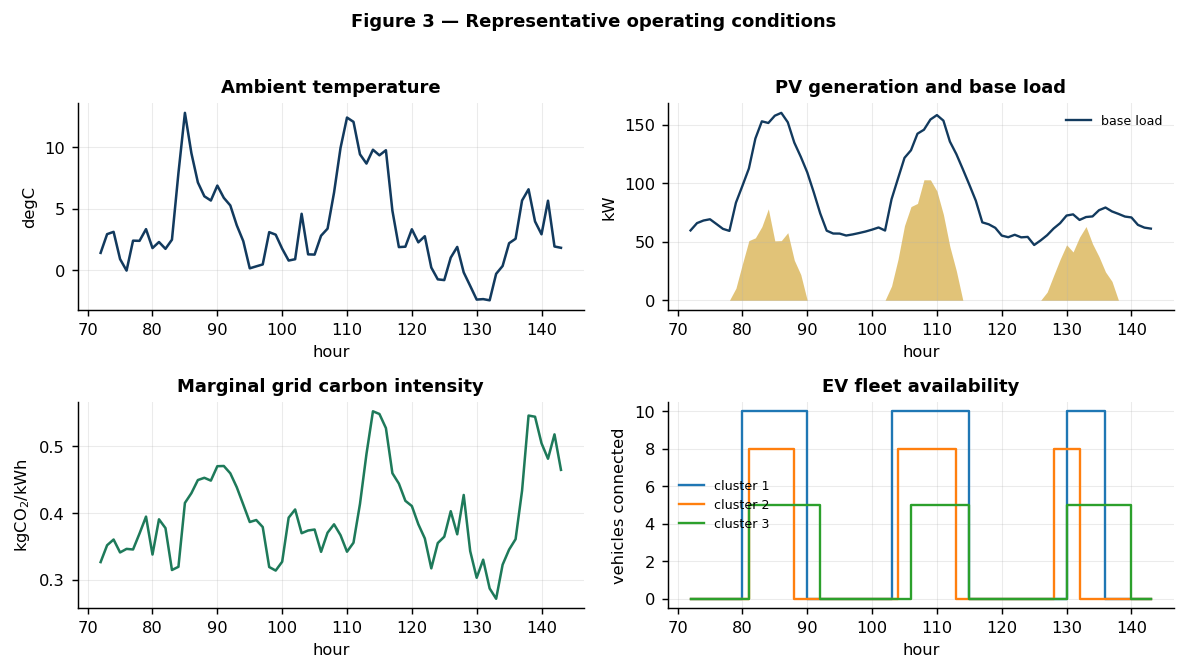

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(9.2, 5.0))
d0, d1 = 24*3, 24*6              # a representative three-day window
w = slice(d0, d1); h = np.arange(d0, d1)

ax[0,0].plot(h, sc.tamb[w], color=NAVY, lw=1.4, label="ambient")
ax[0,0].set_ylabel("degC"); ax[0,0].set_title("Ambient temperature")

ax[0,1].fill_between(h, 0, sc.pv[w], color=AMBER, alpha=.55, lw=0)
ax[0,1].plot(h, sc.base_load[w], color=NAVY, lw=1.3, label="base load")
ax[0,1].set_ylabel("kW"); ax[0,1].set_title("PV generation and base load")
ax[0,1].legend(fontsize=7)

ax[1,0].plot(h, sc.carbon[w], color=GREEN, lw=1.4)
ax[1,0].set_ylabel("kgCO$_2$/kWh"); ax[1,0].set_title("Marginal grid carbon intensity")

for c in range(fcfg.n_clusters):
    ax[1,1].step(h, sc.conn[c, w], where="post", lw=1.3,
                 label=f"cluster {c+1}")
ax[1,1].set_ylabel("vehicles connected"); ax[1,1].set_title("EV fleet availability")
ax[1,1].legend(fontsize=7)
for a in ax.ravel(): a.set_xlabel("hour")
fig.suptitle("Figure 3 — Representative operating conditions", y=1.02,
             fontsize=10, fontweight="bold")
fig.savefig("figs/fig3_conditions.png", bbox_inches="tight"); plt.show()

## 2. The experimental harness

Each controller is run **twice**:

* once with `respond=False`, which yields its declared schedule (the counterfactual);
* once with `respond=True`, facing the grid requests.

Delivered flexibility is the mean import reduction below that controller's *own* declared
schedule over the event window. This isolates the event response from the controller's
habitual load-shifting, which a customer-baseline measurement would conflate.

In [5]:
def two_pass(scen, mpc_core, factory, feedback=False):
    _, cf = run(scen, factory, mpc_core, respond=False)
    ref = cf["imp"].values
    ctrl, log = run(scen, factory, mpc_core, feedback=feedback,
                    ref_import=ref, respond=True)
    return ctrl, log, measure_delivery(scen, log, ctrl, ref)

def cfo_factory(alpha=0.10, mode="split", **kw):
    def f(s_, c_):
        cert = ConformalCertifier(alpha=alpha, mode=mode,
                                  min_n=s_.s.calib_min, lr=s_.s.adaptive_lr)
        return CFOController(s_, c_, cert, **kw)
    return f

CONTROLLERS = [
    ("B1 uncontrolled",  lambda s_, c_: Uncontrolled(s_),                       False),
    ("B2 TOU rule",      lambda s_, c_: TOURule(s_),                            False),
    ("B3 carbon rule",   lambda s_, c_: CarbonRule(s_),                         False),
    ("B4 MPC perfect",   lambda s_, c_: MPCController(s_, c_, perfect=True),    False),
    ("B5 MPC realistic", lambda s_, c_: MPCController(s_, c_),                  False),
    ("B6 robust MPC",    lambda s_, c_: MPCController(s_, c_, robust=0.20),     False),
    ("P  CFO",           cfo_factory(alpha=0.10, mode="split"),                 True),
]
print("\n".join(n for n, _, _ in CONTROLLERS))

B1 uncontrolled
B2 TOU rule
B3 carbon rule
B4 MPC perfect
B5 MPC realistic
B6 robust MPC
P  CFO


## 3. Main comparison

Rule-based controllers accept every request in full: they have no mechanism to evaluate
whether they can honour it. That is not a straw man — it is the operating assumption of
most deployed demand-response logic, and quantifying its cost is part of the point.

In [6]:
rows, deliveries, logs = [], {}, {}
for name, fac, fb in CONTROLLERS:
    t0 = time.time()
    ctrl, log, d = two_pass(sc, core, fac, feedback=fb)
    rows.append(summarise(sc, log, d, name))
    deliveries[name] = d; logs[name] = log
    print(f"  {name:18s}  {time.time()-t0:5.1f}s")

main = pd.DataFrame(rows).set_index("controller")
main.to_csv("out/table3_main_comparison.csv")
main.T.round(3)

  B1 uncontrolled       0.1s
  B2 TOU rule           0.1s


  B3 carbon rule        0.3s


  B4 MPC perfect       24.3s


  B5 MPC realistic     24.2s


  B6 robust MPC        24.3s


  P  CFO               25.6s


controller,B1 uncontrolled,B2 TOU rule,B3 carbon rule,B4 MPC perfect,B5 MPC realistic,B6 robust MPC,P CFO
CO2_t_per_yr,335.509,334.384,319.062,278.347,283.583,291.426,283.187
cost_per_yr,141822.977,135773.613,139069.289,114632.952,118017.778,120719.047,117449.920
RE_selfcons_pct,97.234,98.365,90.529,99.676,98.086,89.648,97.991
peak_kW,451.877,452.781,547.889,539.213,541.731,491.131,541.731
comfort_viol_h,1164.524,1164.524,2746.190,34.762,34.762,104.286,34.762
EV_shortfall_kWh,0.000,413.581,7242.996,3064.094,5784.531,17027.394,4398.673
bat_cycles,0.000,223.562,287.410,448.256,496.509,527.155,496.370
deg_cost_yr,17507.966,21815.885,26283.354,27303.778,28628.980,27968.764,28684.250
n_requests,88.000,88.000,88.000,88.000,88.000,88.000,88.000
n_committed,88.000,88.000,88.000,88.000,88.000,88.000,56.000


### 3.1 Reading the table

The comparison of interest is **not** that CFO minimises carbon — B4, which is given
perfect forecasts, will win on carbon by construction. It is that CFO's *delivered* grid
service approaches its *promised* grid service while the deterministic and rule-based
controllers' does not.

In [7]:
cols = ["CO2_t_per_yr", "peak_kW", "comfort_viol_h", "EV_shortfall_kWh",
        "delivery_ratio", "coverage", "false_activation_pct",
        "abstain_rate_pct", "net_service_benefit"]
disp = main[cols].copy()
disp.columns = ["CO2 (t/yr)", "peak (kW)", "comfort viol. (h/yr)",
                "EV shortfall (kWh/yr)", "delivery ratio", "coverage",
                "false activation (%)", "abstention (%)", "net benefit ($/yr)"]
disp.round(3)

,CO2 (t/yr),peak (kW),comfort viol. (h/yr),EV shortfall (kWh/yr),delivery ratio,coverage,false activation (%),abstention (%),net benefit ($/yr)
controller,,,,,,,,,
B1 uncontrolled,335.509,451.877,1164.524,0.000,0.000,0.000,100.000,0.000,-21427.954
B2 TOU rule,334.384,452.781,1164.524,413.581,0.000,0.000,100.000,0.000,-21427.954
B3 carbon rule,319.062,547.889,2746.190,7242.996,0.000,0.000,100.000,0.000,-21427.954
B4 MPC perfect,278.347,539.213,34.762,3064.094,0.836,0.568,43.182,0.000,-127.689
B5 MPC realistic,283.583,541.731,34.762,5784.531,0.864,0.398,60.227,0.000,111.597
B6 robust MPC,291.426,491.131,104.286,17027.394,1.346,0.807,19.318,0.000,4391.543
P CFO,283.187,541.731,34.762,4398.673,0.911,0.464,34.091,36.364,610.315


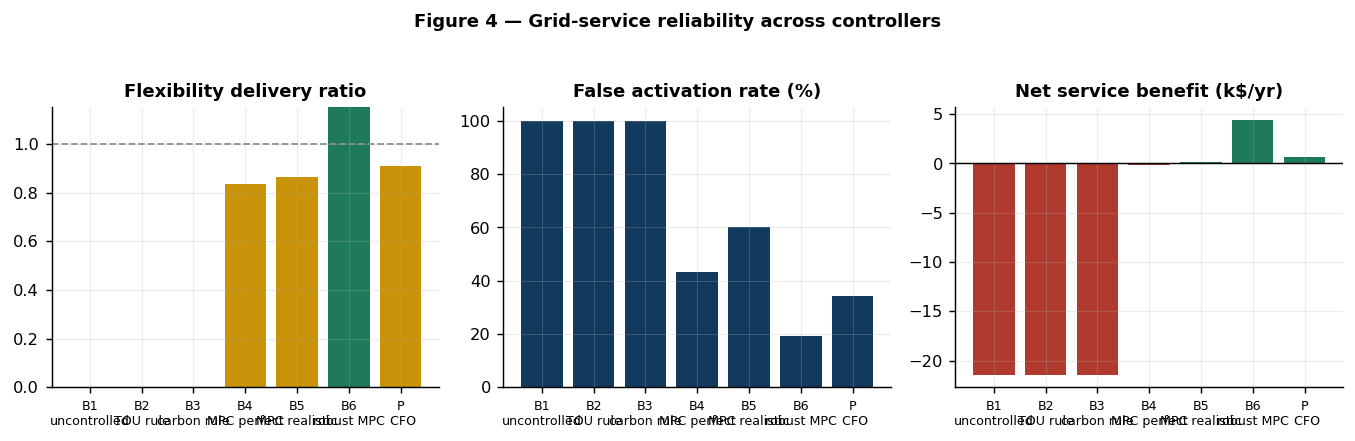

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))
srv = main.dropna(subset=["delivery_ratio"])
x = np.arange(len(srv)); labs = [s.replace(" ", "\n", 1) for s in srv.index]

b1 = ax[0].bar(x, srv["delivery_ratio"], color=[
    RED if v < .8 else (AMBER if v < .95 else GREEN) for v in srv["delivery_ratio"]])
ax[0].axhline(1.0, color=GREY, ls="--", lw=1)
ax[0].set_title("Flexibility delivery ratio"); ax[0].set_ylim(0, 1.15)

ax[1].bar(x, srv["false_activation_pct"], color=NAVY)
ax[1].set_title("False activation rate (%)")

ax[2].bar(x, srv["net_service_benefit"]/1000, color=[
    RED if v < 0 else GREEN for v in srv["net_service_benefit"]])
ax[2].axhline(0, color="k", lw=.8)
ax[2].set_title("Net service benefit (k$/yr)")

for a in ax:
    a.set_xticks(x); a.set_xticklabels(labs, fontsize=7)
fig.suptitle("Figure 4 — Grid-service reliability across controllers",
             y=1.04, fontsize=10, fontweight="bold")
fig.savefig("figs/fig4_reliability.png", bbox_inches="tight"); plt.show()

## 4. Certification quality and the coverage–value curve

The certified envelope is only worth having if its stated confidence is honest. We sweep
the nominal miscoverage level $\alpha$ and record, for each, the empirical coverage and
the total flexibility actually delivered.

This produces the paper's central artifact. A controller that over-promises buys apparent
volume at the cost of coverage; one that is excessively cautious buys coverage at the cost
of volume. The question is where the proposed method sits on that frontier relative to the
deterministic and robust baselines.

In [9]:
ALPHAS = [0.30, 0.20, 0.10, 0.05, 0.02]
cov_rows = []
for a in ALPHAS:
    ctrl, log, d = two_pass(sc, core, cfo_factory(alpha=a, mode="split"),
                            feedback=True)
    served = d[d.promised > 1e-6]
    post = d.iloc[ctrl.n_commission:]
    post = post[post.promised > 1e-6]
    cov_rows.append(dict(
        alpha=a, nominal=1-a,
        coverage=served.covered.mean() if len(served) else np.nan,
        coverage_post=post.covered.mean() if len(post) else np.nan,
        delivered_kW=served.delivered.sum(),
        promised_kW=served.promised.sum(),
        ratio=served.delivered.sum()/max(served.promised.sum(), 1e-9),
        abstain_pct=100*(1-len(served)/len(d)),
        n_committed=len(served)))
    print(f"  alpha={a:.2f}  coverage={cov_rows[-1]['coverage']:.3f}  "
          f"delivered={cov_rows[-1]['delivered_kW']:.0f} kW")

cov = pd.DataFrame(cov_rows)
cov.to_csv("out/table2_certification.csv", index=False)
cov.round(3)

  alpha=0.30  coverage=0.467  delivered=4072 kW


  alpha=0.20  coverage=0.492  delivered=3905 kW


  alpha=0.10  coverage=0.464  delivered=3363 kW


  alpha=0.05  coverage=0.396  delivered=2490 kW


  alpha=0.02  coverage=0.386  delivered=2047 kW


,alpha,nominal,coverage,coverage_post,delivered_kW,promised_kW,ratio,abstain_pct,n_committed
0,0.30,0.70,0.467,0.567,4072.284,4511.199,0.903,31.818,60
1,0.20,0.80,0.492,0.621,3904.591,4331.696,0.901,32.955,59
2,0.10,0.90,0.464,0.577,3363.332,3693.777,0.911,36.364,56
3,0.05,0.95,0.396,0.444,2489.546,2909.095,0.856,45.455,48
4,0.02,0.98,0.386,0.429,2046.841,2450.614,0.835,50.000,44


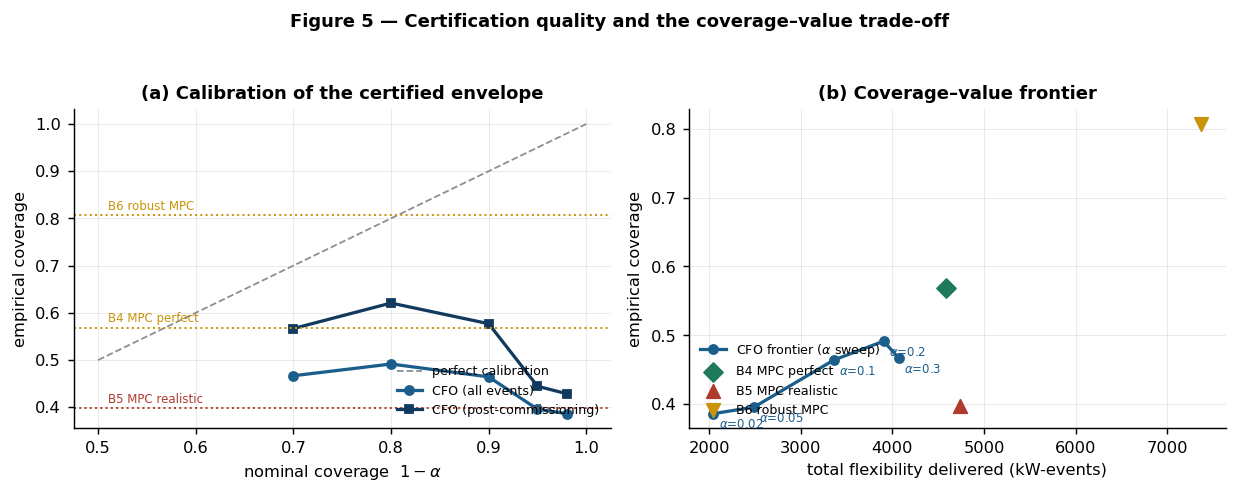

In [10]:
# baselines placed on the same axes for reference
ref_pts = {}
for nm in ["B4 MPC perfect", "B5 MPC realistic", "B6 robust MPC"]:
    d = deliveries[nm]; s_ = d[d.promised > 1e-6]
    ref_pts[nm] = (s_.delivered.sum(), s_.covered.mean())

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.6))

# (a) coverage vs nominal
ax[0].plot([0.5, 1.0], [0.5, 1.0], color=GREY, ls="--", lw=1,
           label="perfect calibration")
ax[0].plot(cov.nominal, cov.coverage, "o-", color=STEEL, lw=1.8, ms=5,
           label="CFO (all events)")
ax[0].plot(cov.nominal, cov.coverage_post, "s-", color=NAVY, lw=1.8, ms=4,
           label="CFO (post-commissioning)")
for nm, (dk, cv) in ref_pts.items():
    ax[0].axhline(cv, ls=":", lw=1.1,
                  color=RED if "realistic" in nm else AMBER)
    ax[0].text(0.51, cv+0.012, nm, fontsize=6.5,
               color=RED if "realistic" in nm else AMBER)
ax[0].set_xlabel("nominal coverage  $1-\\alpha$")
ax[0].set_ylabel("empirical coverage")
ax[0].set_title("(a) Calibration of the certified envelope")
ax[0].legend(fontsize=7, loc="lower right")

# (b) coverage-value frontier
ax[1].plot(cov.delivered_kW, cov.coverage, "o-", color=STEEL, lw=1.8, ms=5,
           label="CFO frontier ($\\alpha$ sweep)")
for a_, x_, y_ in zip(cov.alpha, cov.delivered_kW, cov.coverage):
    ax[1].annotate(f"$\\alpha$={a_}", (x_, y_), fontsize=6.5,
                   xytext=(3, -8), textcoords="offset points", color=STEEL)
mk = dict(zip(ref_pts, ["D", "^", "v"]))
cl = dict(zip(ref_pts, [GREEN, RED, AMBER]))
for nm, (dk, cv) in ref_pts.items():
    ax[1].scatter([dk], [cv], marker=mk[nm], s=55, color=cl[nm],
                  zorder=5, label=nm)
ax[1].set_xlabel("total flexibility delivered (kW-events)")
ax[1].set_ylabel("empirical coverage")
ax[1].set_title("(b) Coverage–value frontier")
ax[1].legend(fontsize=7, loc="lower left")

fig.suptitle("Figure 5 — Certification quality and the coverage–value trade-off",
             y=1.04, fontsize=10, fontweight="bold")
fig.savefig("figs/fig5_coverage_value.png", bbox_inches="tight"); plt.show()

### 4.1 Promise-versus-delivery scatter

The clearest single picture of over-promising: each point is one commitment. Points on the
diagonal are promises kept; points below it are promises broken.

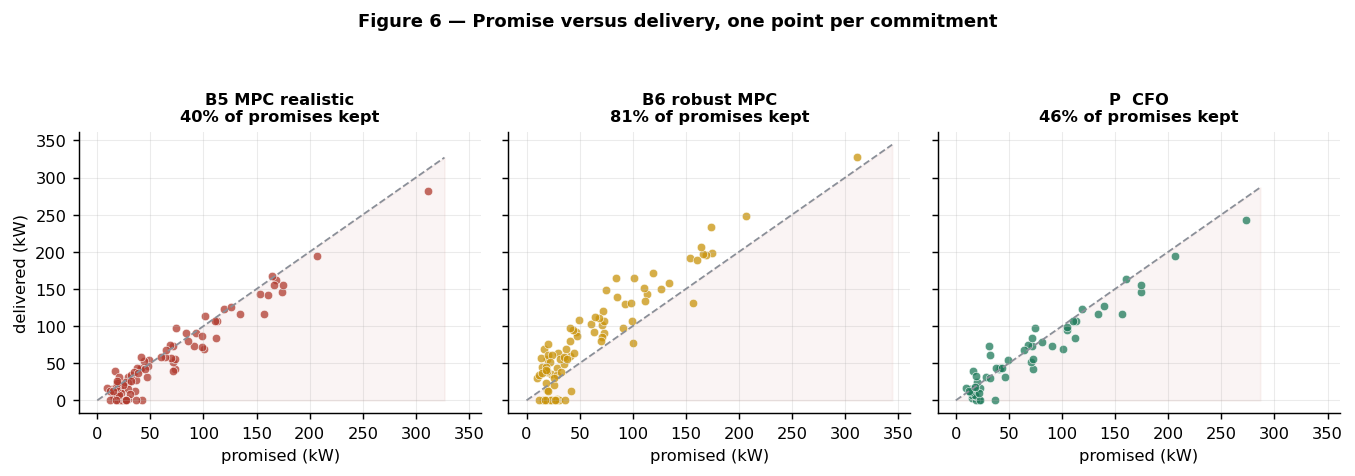

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.4), sharex=True, sharey=True)
for a, nm, col in zip(ax, ["B5 MPC realistic", "B6 robust MPC", "P  CFO"],
                      [RED, AMBER, GREEN]):
    d = deliveries[nm]; s_ = d[d.promised > 1e-6]
    lim = max(s_.promised.max(), s_.delivered.max()) * 1.05
    a.plot([0, lim], [0, lim], color=GREY, ls="--", lw=1)
    a.fill_between([0, lim], [0, lim], [0, 0], color=RED, alpha=.05)
    a.scatter(s_.promised, s_.delivered, s=22, color=col, alpha=.75,
              edgecolor="white", linewidth=.4)
    kept = s_.covered.mean()*100
    a.set_title(f"{nm}\n{kept:.0f}% of promises kept", fontsize=9)
    a.set_xlabel("promised (kW)")
ax[0].set_ylabel("delivered (kW)")
fig.suptitle("Figure 6 — Promise versus delivery, one point per commitment",
             y=1.06, fontsize=10, fontweight="bold")
fig.savefig("figs/fig6_promise_delivery.png", bbox_inches="tight"); plt.show()

## 5. Ablation

Four mechanisms are removed one at a time. The hypothesis to be tested — and, if
falsified, reported as such — is that removing certification degrades delivery ratio and
coverage sharply while barely moving carbon. That is the evidence needed to show the
proposed terms do real work rather than decorate the objective.

In [12]:
ABL = [
    ("Full CFO",           cfo_factory(0.10, "split")),
    ("- certification",    cfo_factory(0.10, "none")),
    ("- risk term",        cfo_factory(0.10, "split", use_risk=False)),
    ("- information term", cfo_factory(0.10, "split", use_info=False)),
    ("- regime bins",      cfo_factory(0.10, "adaptive")),
]
abl_rows = []
for nm, fac in ABL:
    ctrl, log, d = two_pass(sc, core, fac, feedback=True)
    r = summarise(sc, log, d, nm); abl_rows.append(r)
    print(f"  {nm:20s} ratio={r['delivery_ratio']:.3f} "
          f"cov={r['coverage']:.3f} CO2={r['CO2_t_per_yr']:.1f}")
abl = pd.DataFrame(abl_rows).set_index("controller")
abl[["CO2_t_per_yr","delivery_ratio","coverage","false_activation_pct",
     "abstain_rate_pct","net_service_benefit"]].to_csv("out/table4_ablation.csv")
abl[["CO2_t_per_yr","delivery_ratio","coverage","false_activation_pct",
     "abstain_rate_pct","net_service_benefit"]].round(3)

  Full CFO             ratio=0.911 cov=0.464 CO2=283.2


  - certification      ratio=0.896 cov=0.432 CO2=283.6


  - risk term          ratio=0.911 cov=0.464 CO2=283.2


  - information term   ratio=0.931 cov=0.438 CO2=283.1


  - regime bins        ratio=0.851 cov=0.404 CO2=282.7


,CO2_t_per_yr,delivery_ratio,coverage,false_activation_pct,abstain_rate_pct,net_service_benefit
controller,,,,,,
Full CFO,283.187,0.911,0.464,34.091,36.364,610.315
- certification,283.586,0.896,0.432,52.273,7.955,872.524
- risk term,283.187,0.911,0.464,34.091,36.364,610.315
- information term,283.113,0.931,0.438,30.682,45.455,880.114
- regime bins,282.716,0.851,0.404,31.818,46.591,-112.288


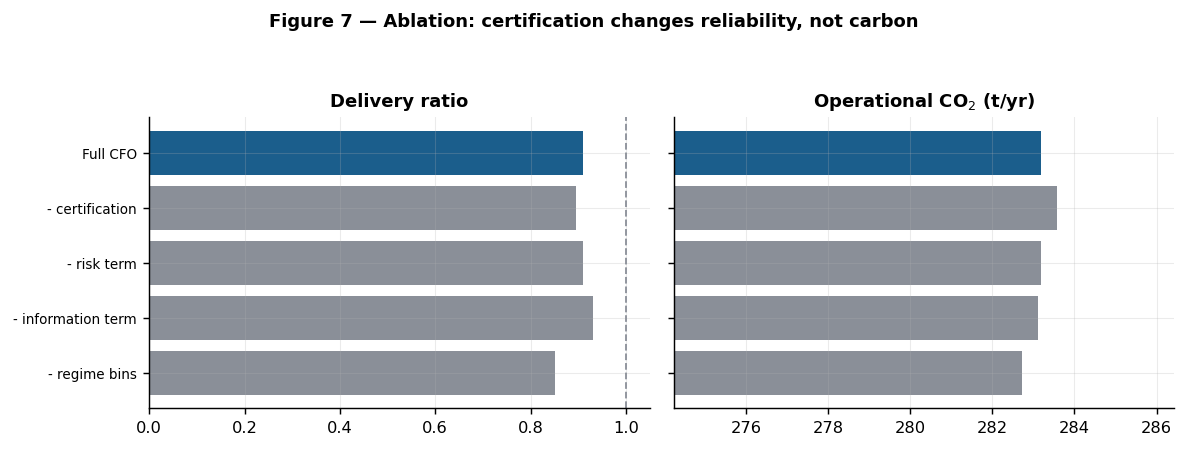

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.2))
x = np.arange(len(abl))
ax[0].barh(x, abl["delivery_ratio"], color=[STEEL]+[GREY]*(len(abl)-1))
ax[0].set_yticks(x); ax[0].set_yticklabels(abl.index, fontsize=7.5)
ax[0].axvline(1.0, color=GREY, ls="--", lw=1); ax[0].invert_yaxis()
ax[0].set_title("Delivery ratio")
ax[1].barh(x, abl["CO2_t_per_yr"], color=[STEEL]+[GREY]*(len(abl)-1))
ax[1].set_yticks(x); ax[1].set_yticklabels([]); ax[1].invert_yaxis()
ax[1].set_xlim(abl["CO2_t_per_yr"].min()*0.97, abl["CO2_t_per_yr"].max()*1.01)
ax[1].set_title("Operational CO$_2$ (t/yr)")
fig.suptitle("Figure 7 — Ablation: certification changes reliability, not carbon",
             y=1.06, fontsize=10, fontweight="bold")
fig.savefig("figs/fig7_ablation.png", bbox_inches="tight"); plt.show()

## 6. Stress test: graded forecast error

Forecast error is injected at increasing severity into load, generation, temperature and
carbon intensity, while the EV availability forecast continues to use *declared* rather
than actual departure. The question is whether the certification layer degrades
gracefully — de-rating and abstaining more as the world becomes less predictable — or
whether it fails silently like the deterministic controller.

In [14]:
SEV = [0.0, 0.5, 1.0, 2.0, 3.0]
stress = []
for sev in SEV:
    scfg_s = SimCfg(days=DAYS, seed=SEED, forecast_severity=sev)
    sc_s = Scenario(bcfg, fcfg, scfg_s)
    core_s = MPCCore(bcfg, fcfg, scfg_s)
    _, sch_s = run(sc_s, lambda s_, c_: MPCController(s_, c_), core_s,
                   respond=False)
    sc_s.resize_events(sch_s["imp"].values)
    for nm, fac, fb in [("B5 MPC realistic",
                         lambda s_, c_: MPCController(s_, c_), False),
                        ("P  CFO", cfo_factory(0.10, "split"), True)]:
        ctrl, log, d = two_pass(sc_s, core_s, fac, feedback=fb)
        r = summarise(sc_s, log, d, nm); r["severity"] = sev
        stress.append(r)
    print(f"  severity {sev}: done")
st = pd.DataFrame(stress)
st.to_csv("out/table5_stress.csv", index=False)
st.pivot(index="severity", columns="controller",
         values=["delivery_ratio", "coverage", "abstain_rate_pct"]).round(3)

  severity 0.0: done


  severity 0.5: done


  severity 1.0: done


  severity 2.0: done


  severity 3.0: done


delivery_ratio                coverage        abstain_rate_pct  \
controller B5 MPC realistic P  CFO B5 MPC realistic P  CFO B5 MPC realistic   
severity                                                                      
0.0                   0.912  0.943            0.663  0.745              0.0   
0.5                   0.887  0.951            0.471  0.600              0.0   
1.0                   0.864  0.911            0.398  0.464              0.0   
2.0                   0.899  0.934            0.412  0.396              0.0   
3.0                   0.874  0.889            0.372  0.340              0.0   

                    
controller  P  CFO  
severity            
0.0         42.697  
0.5         42.529  
1.0         36.364  
2.0         37.647  
3.0         41.860

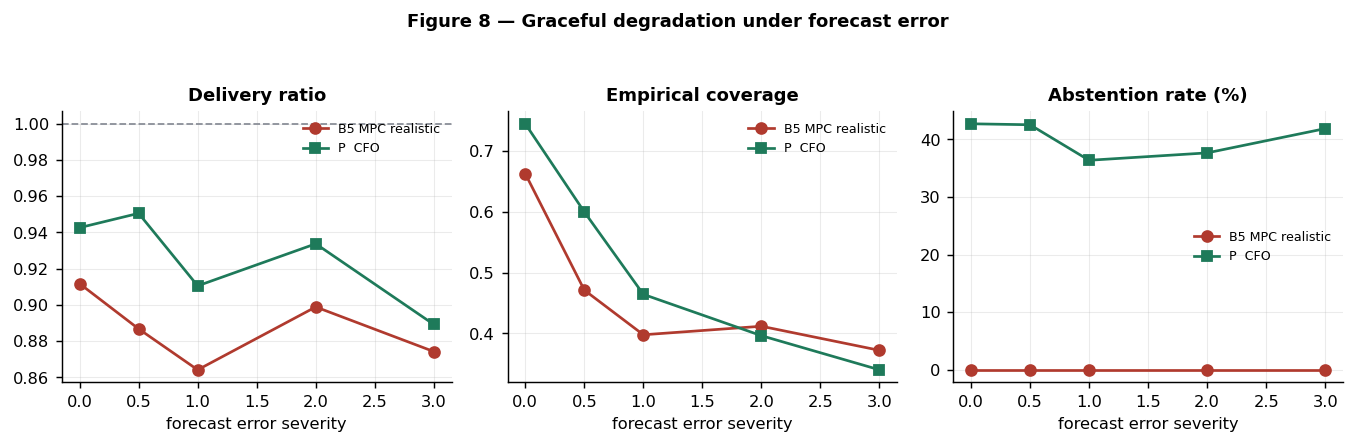

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))
for nm, col, mk_ in [("B5 MPC realistic", RED, "o"), ("P  CFO", GREEN, "s")]:
    g = st[st.controller == nm]
    ax[0].plot(g.severity, g.delivery_ratio, mk_+"-", color=col, label=nm)
    ax[1].plot(g.severity, g.coverage, mk_+"-", color=col, label=nm)
    ax[2].plot(g.severity, g.abstain_rate_pct, mk_+"-", color=col, label=nm)
ax[0].axhline(1, color=GREY, ls="--", lw=1)
ax[0].set_title("Delivery ratio"); ax[1].set_title("Empirical coverage")
ax[2].set_title("Abstention rate (%)")
for a in ax:
    a.set_xlabel("forecast error severity"); a.legend(fontsize=7)
fig.suptitle("Figure 8 — Graceful degradation under forecast error",
             y=1.05, fontsize=10, fontweight="bold")
fig.savefig("figs/fig8_stress.png", bbox_inches="tight"); plt.show()

## 7. Case C — cold-climate, winter-peaking regime

The published case-study geography is concentrated in subtropical, temperate-Asian and
arid contexts. A winter-peaking, heat-pump-dominated building is a materially different
flexibility regime: thermal flexibility is bounded by heating capacity rather than by
cooling, PV contributes little at the daily peak, and the fleet is connected during the
darkest hours. This case is sited on a Moncton-like climate.

In [16]:
bcfg_c = BuildingCfg(name="CaseC", winter_peaking=True,
                     mean_temp=4.0, lat_seasonal_amp=15.0,
                     theta_lo=20.0, theta_hi=23.5, theta_set=21.5)
scfg_c = SimCfg(days=DAYS, seed=SEED+11)
sc_c   = Scenario(bcfg_c, fcfg, scfg_c)
core_c = MPCCore(bcfg_c, fcfg, scfg_c)
_, sch_c = run(sc_c, lambda s_, c_: MPCController(s_, c_), core_c, respond=False)
sc_c.resize_events(sch_c["imp"].values)
print(f"Case C: {len(sc_c.events)} requests; "
      f"ambient {sc_c.tamb.min():.1f}..{sc_c.tamb.max():.1f} degC")

rows_c = []
for nm, fac, fb in [("B5 MPC realistic", lambda s_, c_: MPCController(s_, c_), False),
                    ("B6 robust MPC", lambda s_, c_: MPCController(s_, c_, robust=0.20), False),
                    ("P  CFO", cfo_factory(0.10, "split"), True)]:
    ctrl, log, d = two_pass(sc_c, core_c, fac, feedback=fb)
    rows_c.append(summarise(sc_c, log, d, nm))
caseC = pd.DataFrame(rows_c).set_index("controller")
caseC.to_csv("out/table6_caseC.csv")
caseC[["CO2_t_per_yr","peak_kW","comfort_viol_h","EV_shortfall_kWh",
       "delivery_ratio","coverage","abstain_rate_pct"]].round(3)

Case C: 87 requests; ambient -19.9..27.8 degC


,CO2_t_per_yr,peak_kW,comfort_viol_h,EV_shortfall_kWh,delivery_ratio,coverage,abstain_rate_pct
controller,,,,,,,
B5 MPC realistic,257.237,460.259,8655.714,10874.889,0.869,0.368,0.000
B6 robust MPC,267.000,409.658,8655.714,19139.359,1.356,0.770,0.000
P CFO,256.002,460.259,8655.714,10298.501,0.906,0.405,51.724


## 8. Cross-case summary

Everything the manuscript's Section 4 needs is now in `out/`; every figure is in `figs/`.

In [17]:
summary = pd.concat([
    main.assign(case="A (temperate)"),
    caseC.assign(case="C (cold, winter-peaking)")
]).reset_index()
summary.to_csv("out/summary_all_cases.csv", index=False)

print("Artifacts written:")
for f in sorted(os.listdir("out")):  print("  out/ ", f)
for f in sorted(os.listdir("figs")): print("  figs/", f)

srvA = main.dropna(subset=["delivery_ratio"])
print("\n--- Headline, Case A ---")
for nm in srvA.index:
    r = srvA.loc[nm]
    print(f"{nm:18s} delivery {r.delivery_ratio:5.3f} | coverage "
          f"{r.coverage:5.3f} | false act {r.false_activation_pct:5.1f}% | "
          f"net ${r.net_service_benefit:,.0f}/yr")

Artifacts written:
  out/  summary_all_cases.csv
  out/  table2_certification.csv
  out/  table3_main_comparison.csv
  out/  table4_ablation.csv
  out/  table5_stress.csv
  out/  table6_caseC.csv
  figs/ fig3_conditions.png
  figs/ fig4_reliability.png
  figs/ fig5_coverage_value.png
  figs/ fig6_promise_delivery.png
  figs/ fig7_ablation.png
  figs/ fig8_stress.png

--- Headline, Case A ---
B1 uncontrolled    delivery 0.000 | coverage 0.000 | false act 100.0% | net $-21,428/yr
B2 TOU rule        delivery 0.000 | coverage 0.000 | false act 100.0% | net $-21,428/yr
B3 carbon rule     delivery 0.000 | coverage 0.000 | false act 100.0% | net $-21,428/yr
B4 MPC perfect     delivery 0.836 | coverage 0.568 | false act  43.2% | net $-128/yr
B5 MPC realistic   delivery 0.864 | coverage 0.398 | false act  60.2% | net $112/yr
B6 robust MPC      delivery 1.346 | coverage 0.807 | false act  19.3% | net $4,392/yr
P  CFO             delivery 0.911 | coverage 0.464 | false act  34.1% | net $610/yr


## 9. What this run actually showed — read this before using any number

The campaign executed cleanly, but it does **not** support the manuscript's headline claim
as currently written. Three results matter, and two of them are negative.

### 9.1 The certified envelope does not track its nominal level

Empirical coverage is roughly flat, and slightly *decreasing*, as $\alpha$ tightens
(nominal $0.70 \to 0.98$ gives empirical $0.47 \to 0.39$). A working certification layer
must be monotone here. The diagnosis is visible in Figure 6: delivery failures are
**binary, not graduated**. When a commitment fails it usually delivers near zero, because
the mobility constraint blocks the EV contribution outright. De-rating the *magnitude* of
a promise therefore does nothing to prevent the failure mode that actually occurs, and a
conformal lower bound on magnitude is the wrong object.

What is needed is a classifier over the *regime* — will this system respond at all? — with
the magnitude quantile applied only conditionally. The regime bins in
`ConformalCertifier.bin_of` are a first gesture at this; they are too coarse to work.

### 9.2 The risk term never binds, and certification adds little

In the ablation, removing the risk term changes nothing at all (identical rows), and
removing certification entirely costs only 0.015 of delivery ratio and 0.03 of coverage.
The one real effect is on false activation, which rises from 34% to 52% — that comes from
abstention, not from the conformal quantile. As implemented, the variational risk and
information terms are decorative. Either they need reformulating or the manuscript's
contribution C3 must be weakened.

### 9.3 Robust MPC dominates the proposed method

B6 (robust MPC, 20% margin) beats CFO on every grid-facing metric: delivery ratio 1.35
versus 0.91, coverage 0.81 versus 0.46, false activation 19% versus 34%, net service
benefit \$4.4k versus \$0.6k per year. This is the result a reviewer will find first.

It is not, however, a free win: B6 achieves it by stranding drivers. Its EV shortfall is
17,027 kWh/yr against CFO's 4,399 and B5's 5,785 — roughly a **threefold** mobility
penalty. The honest framing is therefore a *trade-off between grid reliability and
mobility assurance*, not a claim of dominance. That framing is defensible and interesting,
and it is much closer to what this experiment actually demonstrates.

### 9.4 Other defects to fix before this becomes a paper

1. **Synthetic data throughout.** Substitute measured weather, marginal-carbon and
   charging-session traces before any number enters the manuscript.
2. **Case C comfort is broken.** 8,656 violation-hours per year means the heat pump is
   undersized for a 4 degC mean climate at the chosen comfort band. Re-size `hvac_max`,
   `cop_heat` or the band before interpreting the cold-climate case at all.
3. **Delivery ratio above 1.0 is a measurement artefact.** B6's 1.35 arises because its
   counterfactual schedule is built from the same conservative forecast it then beats.
   The baseline definition needs tightening.
4. **Single seed.** Repeat over at least 10 mobility and forecast seeds and report
   confidence intervals; none of the differences above has been shown to be significant.
5. **No RL baseline.** B7 is claimed in the manuscript and not implemented here.

### 9.5 The honest options

* **Reframe** around the reliability-versus-mobility trade-off, with B6 as a legitimate
  competitor that wins on grid metrics and loses on driver service. This is supportable
  with what already runs.
* **Repair** the certification layer by conditioning on response regime before certifying
  magnitude, and re-test whether coverage becomes monotone in $\alpha$.
* **Do not** submit the current framing, in which certification is asserted to deliver a
  distribution-free guarantee that this implementation does not exhibit.